# Perfect and Noisy Boson Sampling

We are interested to simulate a boson sample with 14 photons and 60 modes, order of size comparable to what was done in *Boson Sampling with 20 Input Photons and a 60-Mode Interferometer in a* $10^{14}$*-Dimensional Hilbert Space* [[1]](#References)

In [1]:
from collections import Counter
import gzip
import pickle
import time

import random

import perceval as pcvl
from perceval.algorithm import Sampler

We define all the needed values below. 

## Perfect Boson sampling

In [2]:
n = 14       #number of photons at the input
m = 60       #number of modes
N = 5000000  #number of samplings

### Generating a Haar random Unitary with Perceval

In [3]:
Unitary_60 = pcvl.Matrix.random_unitary(m) #creates a random unitary of dimension 60

### A possible unitary circuit realization of such matrix would be the following.

Here we define a 2-mode unitary circuit that we can use to decompose the 60 mode unitary

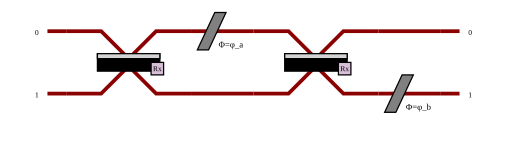

In [4]:
mzi = (pcvl.BS() // (0, pcvl.PS(phi=pcvl.Parameter("φ_a")))
       // pcvl.BS() // (1, pcvl.PS(phi=pcvl.Parameter("φ_b"))))
pcvl.pdisplay(mzi)

Let us decompose the unitary into a Reck's type circuit [[2]](#References) - this makes a huge circuit...

In [5]:
unitary_circuit_60 = pcvl.Circuit.decomposition(Unitary_60, mzi,
                                               phase_shifter_fn=pcvl.PS,
                                               shape=pcvl.InterferometerShape.TRIANGLE)

pcvl.pdisplay(unitary_circuit_60)

### Running Simulation

Now we choose the way to perform the simulation with Perceval. The number of photons is within what we could simulate with a `Naive` backend (see [here](https://perceval.quandela.net/docs/backends.html#naive)), however, the output space is far too big just to enumerate and store the states - so let us go with sampling using `CliffordClifford2017` backend (see [here](https://perceval.quandela.net/docs/backends.html#cliffordclifford2017)).

In [6]:
QPU = pcvl.Processor("CliffordClifford2017", unitary_circuit_60)

Select a random input:

In [7]:
#one can choose which mode he/she wants at input, or we can choose it randomly 
def Generating_Input(n, m, modes = None):
    "This function randomly chooses an input with n photons in m modes."
    if modes == None :
        modes = sorted(random.sample(range(m),n))
    state = "|"
    for i in range(m):
        state = state + "0"*(1 - (i in modes)) +"1"*(i in modes)+ ","*(i < m-1)
    return pcvl.BasicState(state + ">")

input_state = Generating_Input(n, m)
print("The input state: ", input_state)
QPU.with_input(input_state)

The input state:  |0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,1,0,1,0,1>


Just to see that it outputs a statevectors of n photon(s) in m modes.

In [10]:
# Keep all outputs
QPU.min_detected_photons_filter(0)

sampler = Sampler(QPU)

print("The sampled outputs are:")
for out_state in sampler.samples(10)["results"]:
    print(out_state)

The sampled outputs are:
|0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,2,0,0,0,0,0,0,0,0,2,1,0,0,2,0,0,0,0,0,1,0,0,0>
|0,0,0,0,2,0,0,0,0,0,0,1,0,0,1,0,0,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,1,1,0,0,0,0,1,0,0,0,1,0>
|0,0,1,0,0,0,0,0,1,0,0,0,1,2,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0>
|0,0,0,0,0,0,0,1,0,0,2,0,0,0,0,0,1,1,0,0,0,3,1,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>
|1,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,2,0,0,1,0,2,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0>
|1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,1,0,0,0,0,0,1>
|1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,1,0,0,0,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0>
|1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,3,0,0,1,0,1,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0>

We carry out the sampling, we do it N times, it will take some time, let us save the results to a file:

In [ ]:
# if we want to launch parallel process
worker_id=1

#store the input and the unitary
with open("%dphotons_%dmodes_%dsamples-worker%s-unitary.pkl" %(n,m,N,worker_id), 'wb') as f:
    pickle.dump(Unitary_60, f)

with open("%dphotons_%dmodes_%dsamples-worker%s-inputstate.pkl" %(n,m,N,worker_id), 'w') as f:
    f.write(str(input_state)+"\n")


with gzip.open("%dphotons_%dmodes_%dsamples-worker%s-samples.txt.gz" %(n,m,N,worker_id), 'wb') as f:
    start = time.time()
    for _ in range(N):
        f.write((str(sampler.samples(1)["results"][0])+"\n").encode())
    end = time.time()
    f.write(str("==> %d\n" % (end-start)).encode())
f.close()

A little after (4 hours on a 3.1GHz Intel) - we do have 5M samples. We launched this on 32 threads for 2 days and collected 300 batches of 5M samples

Let us analyze the K-first mode bunching on these samples

In [10]:
import gzip

In [11]:
worker_id = 1
count = 0
bunching_distribution = Counter()

with gzip.open("%dphotons_%dmodes_%dsamples-worker%s-samples.txt.gz"%(n,m,N,worker_id), "rt") as f:
    for l in f:
        l = l.strip()
        if l.startswith("|") and l.endswith(">"):
            try:
                st = pcvl.BasicState(l)
                count+=1
                bunching_distribution[st.photon2mode(st.n-1)]+=1
            except Exception:
                pass
print(count, "samples")
print("Bunching Distribution:", "\t".join([str(bunching_distribution[k]) for k in range(m)]))

5000000 samples
Bunching Distribution: 0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	3	0	1	0	4	7	12	15	37	17	72	26	160	202	425	645	1096	1305	1913	1695	2754	3818	5382	11044	11120	11836	15396	15035	38725	39583	60725	73354	91170	97192	109380	170639	266973	179713	364987	501164	543633	592287	700750	1085705


These numbers have been used on 300 samples for certification - see our article on Perceval for more details.

## Boson sampling with non perfect sources

Let us explore around performing Boson sampling with a non perfect source. We declare a source with 90% brightness and purity. Here, we would reach the limits of the simulation if we use the same input as before, as for each photon at the entrance, we multiply by 3 the number of input states (0, 1 or 2 photons at the input), leading to $3^n$ states. To define a source in a `Processor`, we have to define a more general `NoiseModel` that includes the properties of the source.

In [10]:
3 ** n

4782969

In [11]:
noise_model = pcvl.NoiseModel(brightness=0.9, g2=0.1)
QPU = pcvl.Processor("CliffordClifford2017", unitary_circuit_60, noise_model)
QPU.with_input(pcvl.BasicState([0, 1, 1] + (m - 3) * [0]))

We can see what is the source distribution, so how likely a state at the input of the linear circuit will be.

In [12]:
pcvl.pdisplay(QPU.source_distribution, precision=1e-7, max_v=20)

state,probability
"|0,{_:0},{_:0},0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>",0.731684
"|0,0,{_:0},0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>",0.0855385
"|0,{_:0},0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>",0.0855385
"|0,{_:0}{_:2},{_:0},0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>",0.0381629
"|0,{_:0},{_:0}{_:4},0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>",0.0381629
"|0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>",0.01
"|0,0,{_:0}{_:4},0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>",0.0044615
"|0,{_:0}{_:2},0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>",0.0044615
"|0,{_:0}{_:2},{_:0}{_:4},0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>",0.0019905


Now we can launch again starting from cell 8 to use this imperfect QPU with the same nominal input, or from cell 7 for another random input.

## Error Mitigation in Boson Sampling by Photon recycling

Photon recycling, our new error mitigation feature, is a statistical algorithm designed to reduce the effects of photon loss in the output distribution from a linear optics quantum circuit (Reference: [[3]](#References)). It computes an approximate probability distribution for the ideal case of _n_ photons by computing recycled probabilities from the lossy output samples. The following section demonstrates the use of this feature in _Perceval_ on a lossy simulation of Boson Sampling. A 10 mode random unitary circuit with 3 input photons and an imperfect source with low emission probability is used in the example.

In [5]:
Unitary_10 = pcvl.Matrix.random_unitary(10)  # a random unitary of dimension 10
Linear_Circuit_10 = pcvl.Circuit.decomposition(Unitary_10, mzi,
                                               phase_shifter_fn=pcvl.PS,
                                               shape=pcvl.InterferometerShape.TRIANGLE)

In [11]:
noise_model = pcvl.NoiseModel(brightness=0.3)  # imperfect source

# Constructing a Processor with the lossy source and the 10 mode random unitary circuit
lossy_qpu = pcvl.Processor("SLOS", Linear_Circuit_10, noise_model)

lossy_input = pcvl.BasicState([1, 1, 1] + (Linear_Circuit_10.m - 3) * [0])  # Input state with 3 photons
lossy_qpu.with_input(lossy_input)
lossy_qpu.min_detected_photons_filter(1)
# n-2 photons in min detected filter gives the best approximate for output probabilities with photon recycling

Computing and displaying the lossy output samples with photon count less than expected.

In [12]:
# Sampler to create a lossy output sampling
lossy_sampler = Sampler(lossy_qpu)
lossy_output_samples = lossy_sampler.sample_count(100000)['results']

In [13]:
for out_state in lossy_output_samples:
    if out_state.n < 3:
        print(out_state, ':', lossy_output_samples[out_state])

|1,0,0,0,0,0,0,0,0,0> : 1738
|0,1,0,0,0,0,0,0,0,0> : 11765
|0,0,1,0,0,0,0,0,0,0> : 5860
|0,0,0,1,0,0,0,0,0,0> : 7654
|0,0,0,0,1,0,0,0,0,0> : 4582
|0,0,0,0,0,1,0,0,0,0> : 4757
|0,0,0,0,0,0,1,0,0,0> : 10890
|0,0,0,0,0,0,0,1,0,0> : 9218
|0,0,0,0,0,0,0,0,1,0> : 7273
|0,0,0,0,0,0,0,0,0,1> : 3207
|2,0,0,0,0,0,0,0,0,0> : 29
|1,1,0,0,0,0,0,0,0,0> : 434
|1,0,1,0,0,0,0,0,0,0> : 116
|1,0,0,1,0,0,0,0,0,0> : 206
|1,0,0,0,1,0,0,0,0,0> : 100
|1,0,0,0,0,1,0,0,0,0> : 80
|1,0,0,0,0,0,1,0,0,0> : 151
|1,0,0,0,0,0,0,1,0,0> : 46
|1,0,0,0,0,0,0,0,1,0> : 204
|1,0,0,0,0,0,0,0,0,1> : 78
|0,2,0,0,0,0,0,0,0,0> : 1710
|0,1,1,0,0,0,0,0,0,0> : 535
|0,1,0,1,0,0,0,0,0,0> : 1184
|0,1,0,0,1,0,0,0,0,0> : 818
|0,1,0,0,0,1,0,0,0,0> : 449
|0,1,0,0,0,0,1,0,0,0> : 858
|0,1,0,0,0,0,0,1,0,0> : 617
|0,1,0,0,0,0,0,0,1,0> : 1385
|0,1,0,0,0,0,0,0,0,1> : 547
|0,0,2,0,0,0,0,0,0,0> : 412
|0,0,1,1,0,0,0,0,0,0> : 1034
|0,0,1,0,1,0,0,0,0,0> : 323
|0,0,1,0,0,1,0,0,0,0> : 170
|0,0,1,0,0,0,1,0,0,0> : 682
|0,0,1,0,0,0,0,1,0,0> : 700
|0,0,1,0

As expected, the imperfect source led to significant losses in the output sampling. Our Some of this loss can be recovered by using photon recycling as shown in the cell below to obtain a *mitigated distribution* that is closer to the ideal case.

In [19]:
from perceval import photon_recycling
# Ideal photon count = 3 in this case
mitigated_dist = photon_recycling(lossy_output_samples, ideal_photon_count=lossy_input.n)
pcvl.pdisplay(mitigated_dist, max_v=10)  # displaying only the 10 highest probable states in the mitigated distribution

state,probability
"|0,0,0,0,0,0,1,1,1,0>",0.027285
"|0,0,0,0,0,1,1,1,0,0>",0.026835
"|0,1,0,0,0,0,1,0,1,0>",0.025997
"|0,1,0,0,0,0,1,1,0,0>",0.024874
"|0,1,0,1,0,0,0,0,1,0>",0.023755
"|0,1,0,0,0,0,0,1,1,0>",0.023057
"|0,0,0,1,0,0,1,1,0,0>",0.022692
"|0,0,1,0,0,0,1,1,0,0>",0.022161
"|0,1,0,1,0,0,1,0,0,0>",0.021077
"|0,1,0,0,1,0,0,0,1,0>",0.020601


## References

> [1] Hui Wang, et al. Boson Sampling with 20 Input Photons and a 60-Mode Interferometer in a $10^{14}$-Dimensional Hilbert Space. [Physical Review Letters](https://link.aps.org/doi/10.1103/PhysRevLett.123.250503), 123(25):250503, December 2019. Publisher: American Physical Society.

> [2] Michael Reck, Anton Zeilinger, Herbert J Bernstein, and Philip Bertani. Experimental realization of any discrete unitary operator. [Physical review letters](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.73.58), 73(1):58, 1994.


> [3] James Mills and Rawad Mezher. Mitigating photon loss in linear optical quantum circuits: classical postprocessing methods outperforming postselection. [arxiv](https://doi.org/10.48550/arXiv.2405.02278).